# Error Analysis

Investigates model failures across:
1. **Isotype** — are errors concentrated in specific IgG subtypes?
2. **CDR3 length** — do unusually long/short CDR3s cause failures?
3. **Per-metric difficulty** — which regression targets are hardest and why?

In [4]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

OUTPUT_DIR = Path("results/error_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Auto-detect GDPa1 CSV file
GDPA1_DATA_PATH = None
for pattern in ["GDPa1*.csv", "../GDPa1*.csv", "data/GDPa1*.csv", "../data/GDPa1*.csv"]:
    matches = sorted(glob.glob(pattern))
    if matches:
        GDPA1_DATA_PATH = matches[-1]  # take latest version
        break

if GDPA1_DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find GDPa1 CSV. Available CSVs:\n"
        + "\n".join(glob.glob("**/*.csv", recursive=True)[:20])
    )

print(f"Using data file: {GDPA1_DATA_PATH}")

VH_COL = "vh_protein_sequence"
VL_COL = "vl_protein_sequence"
FOLD_COL = "hierarchical_cluster_IgG_isotype_stratified_fold"
LABEL_COL = "label"

REGRESSION_TARGETS = [
    "HIC", "SMAC", "HAC", "PR_Ova", "PR_CHO",
    "SEC_%Monomer", "AC-SINS_pH6.0", "AC-SINS_pH7.4",
    "Tm1", "Tm2", "Titer",
]

Using data file: ../data/GDPa1_v1.2_20250814.csv


In [5]:
df = pd.read_csv(GDPA1_DATA_PATH)

approved_mask = df["highest_clinical_trial_asof_feb2025"] == "Approved"
not_approved_mask = (df["est_status_asof_feb2025"] == "Discontinued") & ~approved_mask
df_model = df[approved_mask | not_approved_mask].copy()
df_model["label"] = approved_mask[approved_mask | not_approved_mask].astype(int)

# Add CDR3 length features (heuristic extraction)
def cdr3_length(seq, chain="H"):
    seq = str(seq).upper()
    if chain == "H":
        m = re.search(r'C([A-Z]{3,30})W[GS]', seq)
    else:
        m = re.search(r'C([A-Z]{3,20})F[GS]', seq)
    return len(m.group(1)) if m else np.nan

df_model["cdr3h_len"] = df_model[VH_COL].apply(lambda s: cdr3_length(s, "H"))
df_model["cdr3l_len"] = df_model[VL_COL].apply(lambda s: cdr3_length(s, "L"))

print(f"CDR3-H length: mean={df_model['cdr3h_len'].mean():.1f}, "
      f"median={df_model['cdr3h_len'].median():.0f}, "
      f"missing={df_model['cdr3h_len'].isna().sum()}")
print(f"CDR3-L length: mean={df_model['cdr3l_len'].mean():.1f}, "
      f"median={df_model['cdr3l_len'].median():.0f}, "
      f"missing={df_model['cdr3l_len'].isna().sum()}")

CDR3-H length: mean=13.0, median=12, missing=0
CDR3-L length: mean=9.1, median=9, missing=1


## Approval Errors by Isotype

In [6]:
# Check which isotype column exists
isotype_candidates = ["isotype", "Isotype", "IgG_subclass", "igg_subclass"]
isotype_col = None
for c in isotype_candidates:
    if c in df_model.columns:
        isotype_col = c
        break

if isotype_col is None:
    # Try to find any column containing 'isotype' or 'igg'
    for c in df_model.columns:
        if "isotype" in c.lower() or "igg" in c.lower():
            isotype_col = c
            break

if isotype_col:
    print(f"Using isotype column: '{isotype_col}'")
    print(df_model[isotype_col].value_counts())
else:
    print("No isotype column found. Available columns:")
    print([c for c in df_model.columns if "ig" in c.lower() or "type" in c.lower() or "class" in c.lower()])

Using isotype column: 'hierarchical_cluster_IgG_isotype_stratified_fold'
hierarchical_cluster_IgG_isotype_stratified_fold
0    47
2    41
1    39
3    37
4    34
Name: count, dtype: int64


Approval rate by isotype:
                                                  approved  total  approval_rate
hierarchical_cluster_IgG_isotype_stratified_fold                                
0                                                       28     47          0.596
2                                                       20     41          0.488
1                                                       22     39          0.564
3                                                       17     37          0.459
4                                                       19     34          0.559


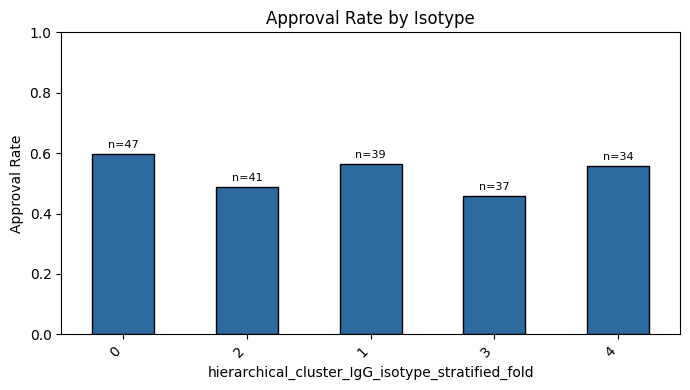

In [7]:
# Approval rate by isotype
if isotype_col:
    iso_stats = (
        df_model.groupby(isotype_col)[LABEL_COL]
        .agg(["sum", "count"])
        .rename(columns={"sum": "approved", "count": "total"})
    )
    iso_stats["approval_rate"] = (iso_stats["approved"] / iso_stats["total"]).round(3)
    iso_stats = iso_stats.sort_values("total", ascending=False)

    print("Approval rate by isotype:")
    print(iso_stats.to_string())

    fig, ax = plt.subplots(figsize=(7, 4))
    iso_stats["approval_rate"].plot(kind="bar", ax=ax, color="#2d6a9f", edgecolor="black")
    ax.set_ylabel("Approval Rate")
    ax.set_title("Approval Rate by Isotype")
    ax.set_ylim(0, 1)
    for i, (idx, row) in enumerate(iso_stats.iterrows()):
        ax.text(i, row["approval_rate"] + 0.02, f"n={int(row['total'])}", ha="center", fontsize=8)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "approval_by_isotype.png", dpi=150)
    plt.show()
else:
    print("Skipping isotype analysis — no column found.")

## Approval Errors by CDR3 Length

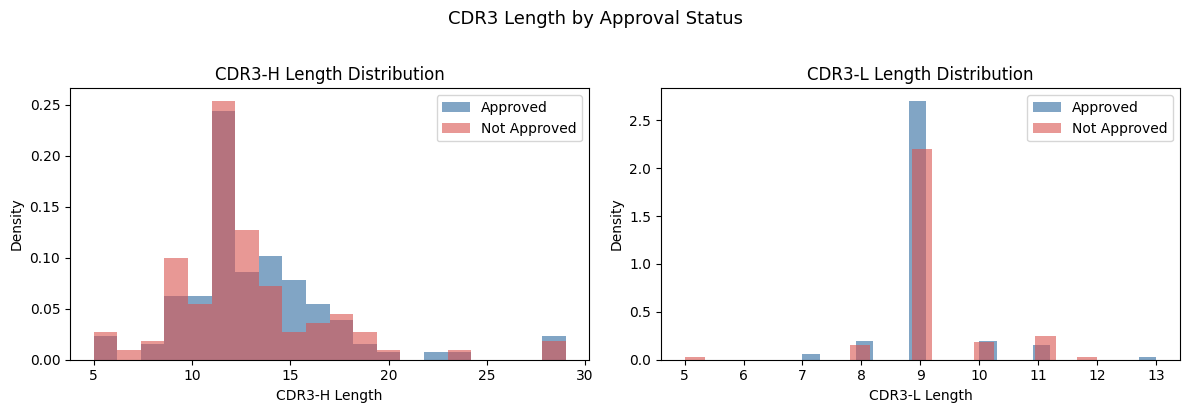

CDR3-H: approved median=13, not-approved median=12, Mann-Whitney p=0.23
CDR3-L: approved median=9, not-approved median=9, Mann-Whitney p=0.337


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, (col, chain) in enumerate([("cdr3h_len", "CDR3-H"), ("cdr3l_len", "CDR3-L")]):
    ax = axes[i]
    subset = df_model.dropna(subset=[col])
    approved = subset[subset[LABEL_COL] == 1][col]
    not_approved = subset[subset[LABEL_COL] == 0][col]

    ax.hist(approved, bins=20, alpha=0.6, label="Approved", color="#2d6a9f", density=True)
    ax.hist(not_approved, bins=20, alpha=0.6, label="Not Approved", color="#d9534f", density=True)
    ax.set_xlabel(f"{chain} Length")
    ax.set_ylabel("Density")
    ax.set_title(f"{chain} Length Distribution")
    ax.legend()

plt.suptitle("CDR3 Length by Approval Status", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cdr3_length_by_approval.png", dpi=150, bbox_inches="tight")
plt.show()

# Statistical test
from scipy.stats import mannwhitneyu
for col, chain in [("cdr3h_len", "CDR3-H"), ("cdr3l_len", "CDR3-L")]:
    subset = df_model.dropna(subset=[col])
    a = subset[subset[LABEL_COL] == 1][col]
    b = subset[subset[LABEL_COL] == 0][col]
    stat, pval = mannwhitneyu(a, b, alternative="two-sided")
    print(f"{chain}: approved median={a.median():.0f}, not-approved median={b.median():.0f}, "
          f"Mann-Whitney p={pval:.3g}")

## Per-Metric Difficulty Analysis

In [10]:
# Load regression results
lora_reg = pd.read_csv("ablang2_developability/regression_cv_results.csv")

reg_summary = (
    lora_reg.groupby("target")["spearman_rho"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "rho_mean", "std": "rho_std", "count": "n_folds"})
    .round(3)
    .sort_values("rho_mean")
    .reset_index()
)

# Add sample counts
sample_counts = {}
for t in REGRESSION_TARGETS:
    if t in df.columns:
        sample_counts[t] = df[t].notna().sum()
reg_summary["n_samples"] = reg_summary["target"].map(sample_counts)

# Add coefficient of variation of the raw target
target_cv = {}
for t in REGRESSION_TARGETS:
    if t in df.columns:
        vals = df[t].dropna()
        target_cv[t] = (vals.std() / vals.mean()) if vals.mean() != 0 else np.nan
reg_summary["target_CV"] = reg_summary["target"].map(target_cv).round(3)

print("Per-metric difficulty (sorted by ρ, ascending = hardest first):")
print(reg_summary.to_string(index=False))
reg_summary.to_csv(OUTPUT_DIR / "per_metric_difficulty.csv", index=False)

Per-metric difficulty (sorted by ρ, ascending = hardest first):
       target  rho_mean  rho_std  n_folds  n_samples  target_CV
          Tm2     0.099    0.174        5        193      0.037
       PR_CHO     0.117    0.194        5        197      0.908
          Tm1     0.149    0.103        5        234      0.030
          HIC     0.158    0.109        5        242      0.120
         SMAC     0.169    0.252        5        242      0.312
        Titer     0.294    0.101        5        239      0.510
AC-SINS_pH6.0     0.303    0.087        5        242      2.130
       PR_Ova     0.366    0.130        5        197      1.148
AC-SINS_pH7.4     0.448    0.156        5        242      1.365
          HAC     0.536    0.118        5         94      0.346


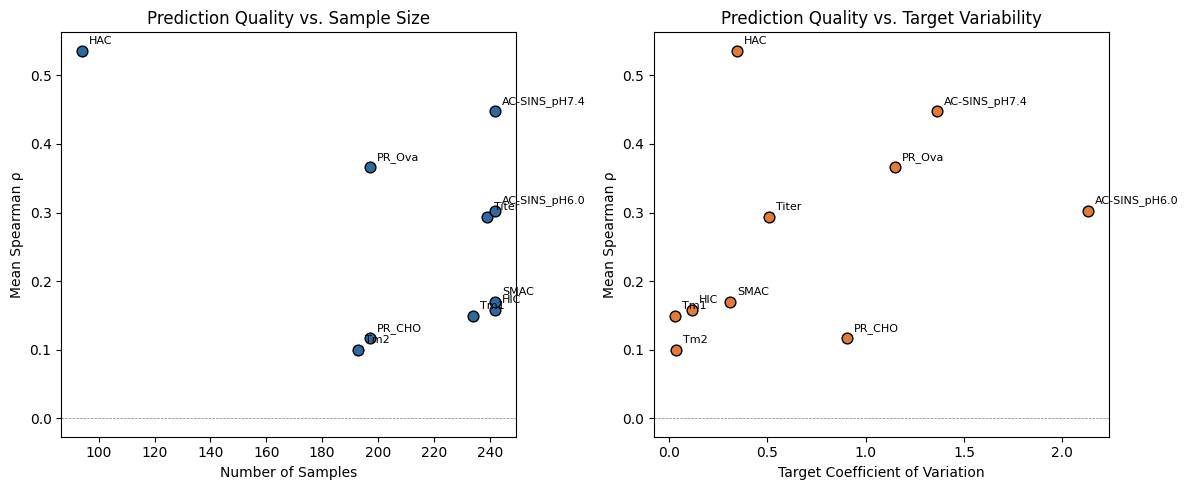

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ρ vs sample count
ax = axes[0]
ax.scatter(reg_summary["n_samples"], reg_summary["rho_mean"], s=60, color="#2d6a9f", edgecolor="black")
for _, row in reg_summary.iterrows():
    ax.annotate(row["target"], (row["n_samples"], row["rho_mean"]),
                fontsize=8, textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("Number of Samples")
ax.set_ylabel("Mean Spearman ρ")
ax.set_title("Prediction Quality vs. Sample Size")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)

# ρ vs target CV
ax = axes[1]
valid = reg_summary.dropna(subset=["target_CV"])
ax.scatter(valid["target_CV"], valid["rho_mean"], s=60, color="#e07b39", edgecolor="black")
for _, row in valid.iterrows():
    ax.annotate(row["target"], (row["target_CV"], row["rho_mean"]),
                fontsize=8, textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("Target Coefficient of Variation")
ax.set_ylabel("Mean Spearman ρ")
ax.set_title("Prediction Quality vs. Target Variability")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "metric_difficulty_scatter.png", dpi=150)
plt.show()

## Hardest Metrics Deep Dive: Tm2 and SEC %Monomer

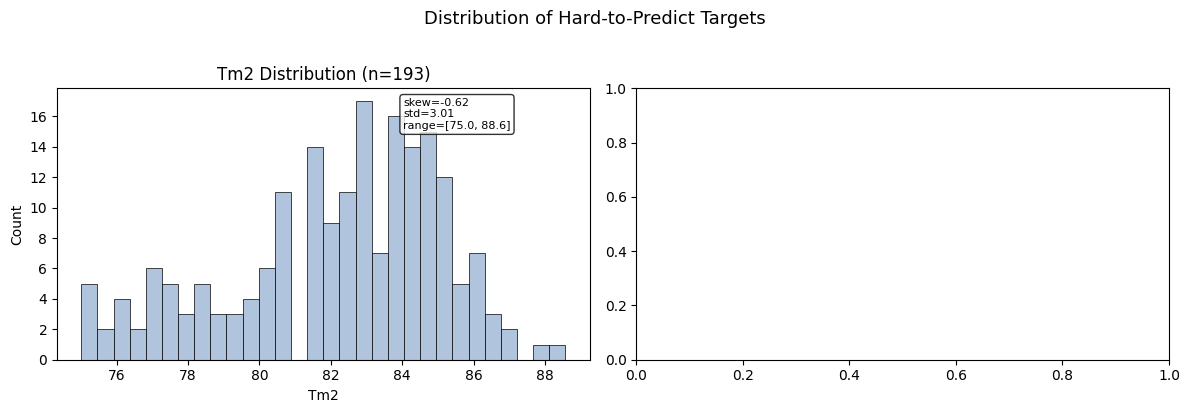


These targets likely have near-zero ρ due to:
  - SEC_%Monomer: most values clustered near 100% → very low variance
  - Tm2: may have high measurement noise or bimodal distribution


In [12]:
hard_targets = ["Tm2", "SEC_%Monomer"]

fig, axes = plt.subplots(1, len(hard_targets), figsize=(12, 4))

for i, target in enumerate(hard_targets):
    if target not in df.columns:
        continue
    ax = axes[i]
    vals = df[target].dropna()
    ax.hist(vals, bins=30, color="#b0c4de", edgecolor="black", linewidth=0.5)
    ax.set_xlabel(target)
    ax.set_ylabel("Count")
    ax.set_title(f"{target} Distribution (n={len(vals)})")

    # Annotate skewness
    from scipy.stats import skew
    sk = skew(vals)
    ax.annotate(f"skew={sk:.2f}\nstd={vals.std():.2f}\nrange=[{vals.min():.1f}, {vals.max():.1f}]",
                xy=(0.65, 0.85), xycoords="axes fraction", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

plt.suptitle("Distribution of Hard-to-Predict Targets", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "hard_targets_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nThese targets likely have near-zero ρ due to:")
print("  - SEC_%Monomer: most values clustered near 100% → very low variance")
print("  - Tm2: may have high measurement noise or bimodal distribution")